In [1]:
from unc_handling import UG_prompter
from DataLoader import DataLoader
from segmentation import Segmentation
from evaluation import Evaluator
import pandas as pd
import matplotlib.pyplot as plt


root = r"C:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\data\LUNDPROBE\ExtendedSamples\development"
methods_available = ["raycast", "local_normals"]
method = methods_available[0]
run_eval = True

data = DataLoader(parentfolder=root,subject_nr=0,volume_of_interest="CTVT",verbose=True)
unc_handler = UG_prompter(data=data)
seg_handler = Segmentation(data=data)

results = []

Loaded subject newAcq_050f229dc2bdb64c with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024), Ground truth shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)
Initilialized UG_prompter for subject 0 with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024).
Initialized Segmentation for subject 0 with volume of interest 'CTVT'
Mask shape: (88, 1024, 1024)
Building SAM predictor from checkpoint: checkpoints/MedSAM2_latest.pt


c:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\sam2\modeling\sam\transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


In [2]:
for nr_of_partitions in [1,2,3,4,5,6,7,8,9,10,11,13,15,17,19,21,25]:
    print(f"Running segmentation with {nr_of_partitions} partitions...")

    # Reset prompts from previous run
    seg_handler.prompt_dict_list = []
    seg_handler.prompts_by_slice = {}
    seg_handler.prompt_sets = {}

    unc_handler.threshold_uncertainty_map(
        unc_threshold=0.033470,
        target_mm=3.0,
        step_fraction=0.01
    )

    unc_handler.compute_band_thickness(method=method)

    prompts = unc_handler.generate_prompts_nietjes(
        unc_band_thr_mm=3.0,
        interpix_dist=3,
        pixel_interval=10,
        angle_step=10,
        method=method
    )

    bbox_prompts = unc_handler.generate_prompts_boxes(band_threshold=0.0)

    propagation_style = "central_partitions"

    seg_handler.load_dense_prompt()
    seg_handler.add_prompt_dict(prompt_dict=prompts)
    seg_handler.check_loaded_prompts()
    seg_handler.construct_prompts()

    seg_handler.run_segmentation_sets(propagation_style=propagation_style, nr_propagation_slices=5, weighting_strategy="custom", weighting_list=[0.0,0.0,0.1,0.9], threshold=0.0, bbox_prompts_by_slice=bbox_prompts)
    seg_handler.remove_distant_slices(tolerance_frames=0)

    eval_handler = Evaluator(segmentation=seg_handler)
    metrics = eval_handler.compute_all(surface_dice_tol=1.0)

    results.append({
        "nr_of_partitions": nr_of_partitions,
        "HD95_mm": metrics["HD95_mm"],
        "SurfaceDice@1.0mm": metrics["SurfaceDice@1.0mm"],
    })

# Create dataframe
df_results = pd.DataFrame(results)

# Show table
display(df_results)

# Save to Excel
df_results.to_excel("partition_results_promptwindow_usage.xlsx", index=False)

Running segmentation with 1 partitions...
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, np.float64(10.235466847817102), np.float64(5.456311207678583), np.float64(4.32663340990742), np.float64(2.978833386053642), np.float64(2.4449222654932075), np.float64(2.1356444822417364), np.float64(1.8003222540848784), np.float64(1.4877889152202342), np.float64(1.43570002540946), np.float64(1.3705889131459925), np.float64(1.3705889131459925), np.float64(1.3347778014010854), np.float64(1.5268555825783148), np.float64(1.9924000352621078), np.float64(2.4351555986536875), np.float64(2.4091111537483005), np.float64(2.663044491575824), np.float64(4.124788961890671), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Added new prompt dict with slices: [28,

c:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\sam2\sam2_video_predictor_npz.py:965: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Adding prompt(s) on slice 28
Adding prompt(s) on slice 29
Adding prompt(s) on slice 30
Adding prompt(s) on slice 31
Adding prompt(s) on slice 32
Adding prompt(s) on slice 33
Forward propagation from slice 30...


propagate in video: 100%|██████████| 58/58 [00:12<00:00,  4.67it/s]


Backward propagation from slice 30...


...

propagate in video: 100%|██████████| 47/47 [00:11<00:00,  4.06it/s]


Backward propagation from slice 41...


propagate in video: 100%|██████████| 42/42 [00:09<00:00,  4.35it/s]


Kept slices 27 to 44. Removed predicted segmentation outside dense mask ±0 slices.


,nr_of_partitions,HD95_mm,SurfaceDice@1.0mm
0,1,6.609141,0.386227
1,2,6.609141,0.386227
2,3,6.609141,0.386227
3,4,6.609141,0.386227
4,5,6.609141,0.386227
5,6,6.609141,0.386227
6,7,6.609141,0.386227
7,8,6.609141,0.386227
8,9,6.609141,0.386227
9,10,6.609141,0.386227


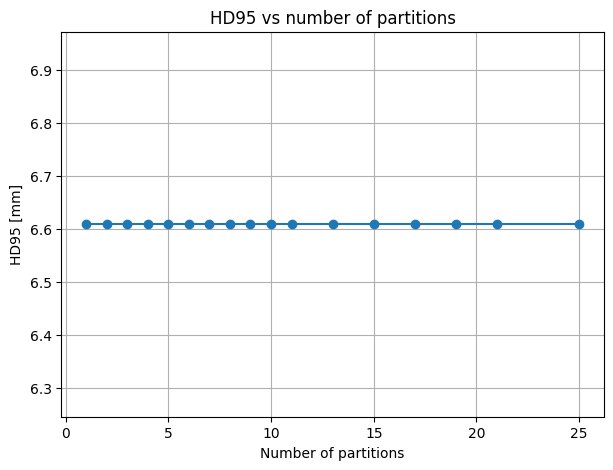

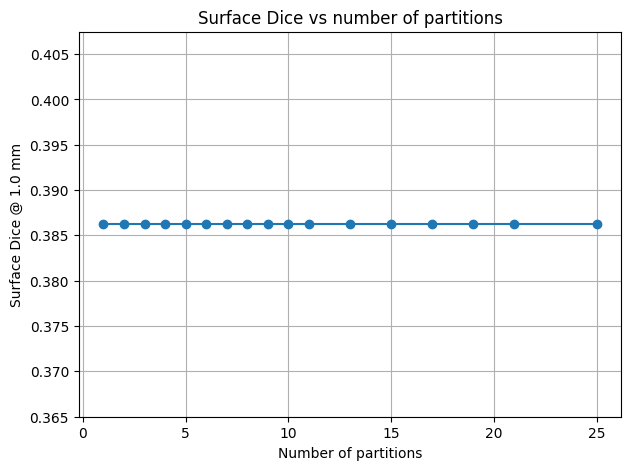

In [3]:
# Plot HD95
plt.figure(figsize=(7, 5))
plt.plot(df_results["nr_of_partitions"], df_results["HD95_mm"], marker="o")
plt.xlabel("Number of partitions")
plt.ylabel("HD95 [mm]")
plt.title("HD95 vs number of partitions")
plt.grid(True)
plt.show()

# Plot Surface Dice
plt.figure(figsize=(7, 5))
plt.plot(df_results["nr_of_partitions"], df_results["SurfaceDice@1.0mm"], marker="o")
plt.xlabel("Number of partitions")
plt.ylabel("Surface Dice @ 1.0 mm")
plt.title("Surface Dice vs number of partitions")
plt.grid(True)
plt.show()